# DatasetList test

In this notebook we test the functionalities of the `DatasetList` class.

## Libraries import

In [1]:
from caits.dataset import CoreArray, DatasetList
from caits.loading import load_dir
from caits.filtering import filter_butterworth
from caits.properties import magnitude_signal

## Global Vars

In [2]:
SAMPLE_RATE = 100
WS_SECONDS = 1.0 # seconds (300 ms)
OVERLAP_PERCENTAGE = 0.0 # percentage

WS_SAMPLES = int(WS_SECONDS * SAMPLE_RATE)
OVERLAP_SAMPLES = int(OVERLAP_PERCENTAGE * WS_SAMPLES)
CLASS_NAMES = ["02a", "03a"]

print(f"Size (in samples) of a single window, should be : {WS_SAMPLES}")
print(f"Size (in samples) of the overlap is {OVERLAP_SAMPLES}, so {WS_SAMPLES - OVERLAP_SAMPLES} samples")
print("are shiffted every time to the right of the x seconds buffer size (in our case the input signal)")

Size (in samples) of a single window, should be : 100
Size (in samples) of the overlap is 0, so 100 samples
are shiffted every time to the right of the x seconds buffer size (in our case the input signal)


## Dataset loading

We load the data/GestureSet_small for this notebook.

In [3]:
pilot_path = "data/pilot"
datasetListObj = load_dir(pilot_path, type="csv")
datasetListObj

Loading data files: 100%|██████████| 3/3 [00:00<00:00, 530.99it/s]


DatasetList object with 3 instances

In [4]:
datasetListObj.X[0].values.shape

(2000, 6)

In [5]:
type(datasetListObj.y)

caits.dataset._core._array.CoreArray

In [6]:
from caits.visualization import plot_signal

In [7]:
from caits.loading import json_loader
from caits.performance.utils import get_gt_events_from_dict

events_dict = json_loader(pilot_path)

# extracts ground truths for whole pilot dataset and represent them as a list of tuples of (start, end, class)
ground_truths_dict = get_gt_events_from_dict(
    events_dict, class_names=CLASS_NAMES, sr=SAMPLE_RATE
)
ground_truths_dict

2026-03-12 11:37:13.334219: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-12 11:37:13.334256: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-12 11:37:13.334281: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-12 11:37:13.341142: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 11:37:14.021641: W tensorflow/compiler/

{'02a_777_1475_02a_8_0_100_AccGyr_1_1_1_0_00_61964f51d11ec26c3bbde60c': [(777,
   1475,
   0)],
 '02a_524_946_02a_1_0_100_AccGyr_1_1_1_0_00_61683eb7ed1368992649f25f': [(524,
   946,
   0)],
 '03a_1753_2417_03a_3_0_100_AccGyr_1_1_1_0_00_61683eb7ed1368992649f257': [(1753,
   2417,
   1)]}

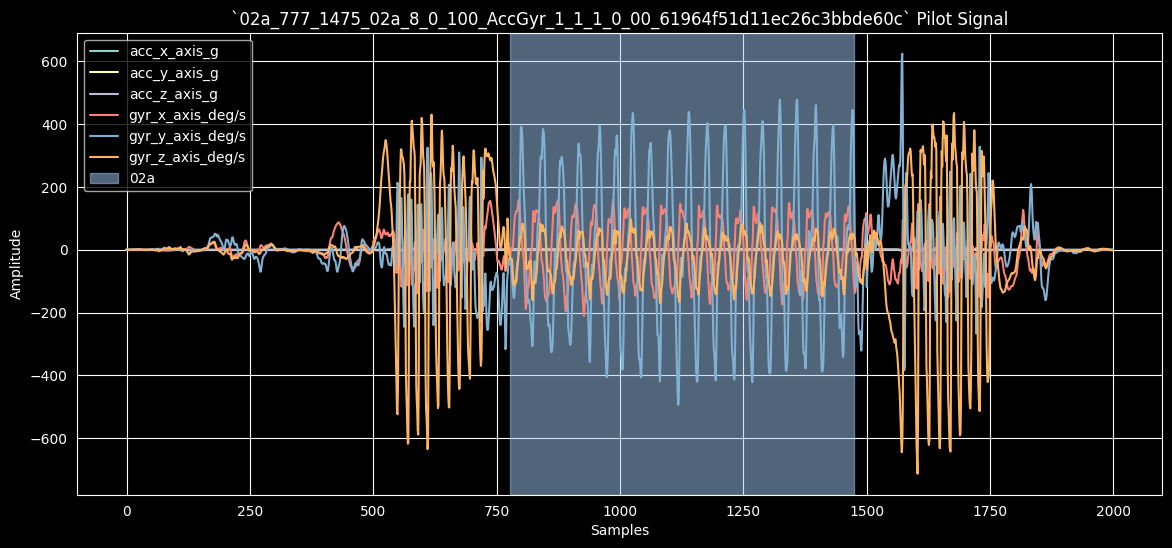

In [8]:
signal_fig = plot_signal(
    datasetListObj.X[0].values,
    sr=SAMPLE_RATE,
    title=f"`{datasetListObj._id[0]}` Pilot Signal",
    channels=datasetListObj.X[0].keys()["axis_1"],
    mode="samples", # change to "time" for time plotting
    figsize=(14, 6),
    events=ground_truths_dict[datasetListObj._id[0]], # get the ground truths for the first signal
    class_names=CLASS_NAMES
)

In [9]:
### Add code for model and pipeline to train on GestsureSet_small

In [10]:
datasetListObj.X[0].values.shape[0]

2000

In [11]:
import numpy as np

dummy_probas = np.random.rand(int(datasetListObj.X[0].shape[0] / SAMPLE_RATE), 2)
dummy_probas.min(), dummy_probas.max(), dummy_probas.shape

(0.0018602743519144926, 0.9434666818072552, (20, 2))

In [12]:
model = lambda x: np.random.rand(int(datasetListObj.X[0].shape[0] / SAMPLE_RATE), 2)

In [13]:
from caits.performance.utils import generate_probabilities

transormed_instance = datasetListObj.X[0].values
multiple_probabilities = generate_probabilities(model=model, X=transormed_instance, repeats=50)
multiple_probabilities.shape

(50, 20, 2)

In [14]:
mean_probabilities = np.mean(multiple_probabilities, axis=0)
mean_probabilities.shape

(20, 2)

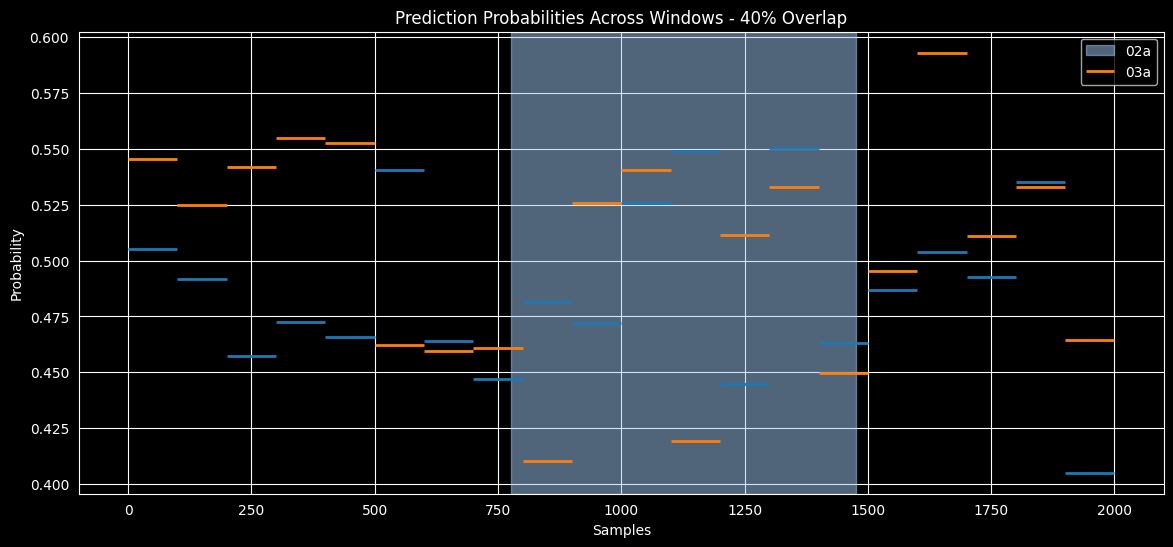

In [15]:
from caits.visualization import plot_prediction_probabilities

pred_probas_fig = plot_prediction_probabilities(
    mean_probabilities,
    sr=SAMPLE_RATE,
    ws=WS_SECONDS,
    overlap_percentage=OVERLAP_PERCENTAGE,
    class_names=CLASS_NAMES,
    figsize=(14, 6),
    mode="samples",
    events=ground_truths_dict[datasetListObj._id[0].split(".")[0]], # get the ground truths for the first signal
    title=f"Prediction Probabilities Across Windows - {2/5*100:.0f}% Overlap",
)

In [16]:
from caits.performance.utils import interpolate_probabilities

interpolated_probas = interpolate_probabilities(
    probabilities=mean_probabilities,
    sr=SAMPLE_RATE,
    ws=WS_SECONDS,
    overlap_percentage=OVERLAP_PERCENTAGE,
    interp_choice=3,
)
interpolated_probas.shape

(2000, 2)

In [17]:
# Apply a low pass butterworth filter
smoothed_probas = np.array(
    [
        filter_butterworth(array=cls_probas, fs=100, filter_type="lowpass", cutoff_freq=2, order=3)
        for cls_probas in interpolated_probas.T
    ]
).T
smoothed_probas.shape

(2000, 2)

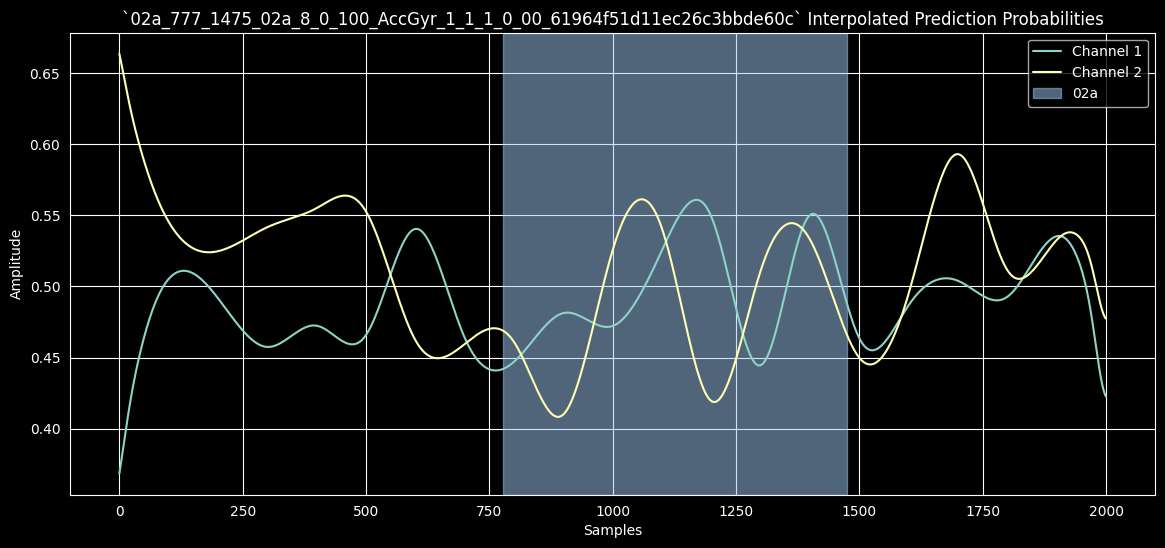

In [18]:
pilot_signal = plot_signal(
    smoothed_probas,
    sr=SAMPLE_RATE,
    title=f"`{datasetListObj._id[0]}` Interpolated Prediction Probabilities",
    mode="samples",
    class_names=CLASS_NAMES,
    figsize=(14, 6),
    events=ground_truths_dict[datasetListObj._id[0]], # get the ground truths for the first signal
    # class_names=["Cough Episodes", "Envirnomental Sounds"]
)

In [19]:
from caits.performance.detection import apply_probability_threshold, get_continuous_events, apply_duration_threshold

In [20]:
# Apply a probability threshold to the interpolated probabilities
# and a `at least event time` duration
thresholded_probas = apply_probability_threshold(interpolated_probs=smoothed_probas, threshold=0.6)
# we call them potenital events because duration threshold rule might not be applied 
# Each continuous event, needs to be > than a user defined duration threshold
potential_events = get_continuous_events(probabilities=thresholded_probas)
potential_events

[(0, 41, 1)]

In [21]:
threshold_probas, predicted_events = apply_duration_threshold(
    interpolated_probs=thresholded_probas, 
    potential_events=potential_events, 
    sr=SAMPLE_RATE, 
    duration_threshold=0.3
)

predicted_events

[(0, 41, 1)]

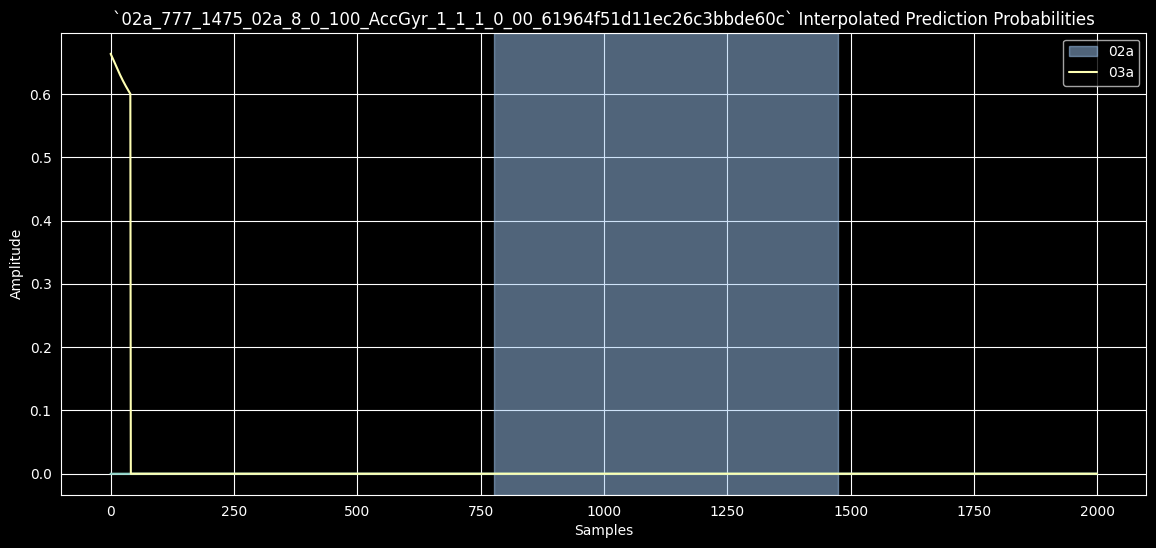

In [22]:
pilot_signal = plot_signal(
    threshold_probas,
    sr=SAMPLE_RATE,
    title=f"`{datasetListObj._id[0]}` Interpolated Prediction Probabilities",
    mode="samples",
    channels=CLASS_NAMES, # [f"{CLASS_NAMES[i]} Interpolated Probabilities" for i in range(len(CLASS_NAMES))],
    figsize=(14, 6),
    events=ground_truths_dict[datasetListObj._id[0]], # get the ground truths for the first signal
    class_names=CLASS_NAMES
)

In [23]:
from caits.performance.detection import classify_events

print(f"Predicted Events: {predicted_events}")
ground_truths = ground_truths_dict[datasetListObj._id[0].split(".")[0]]
print(f"Ground truth Events: {ground_truths}")

iou_th = 0.5
insertions, corrects, substitutions, deletions = classify_events(
    predicted_events, ground_truths, IoU_th=iou_th
)

print(f"Insertions: {insertions}", f"Corrects: {corrects}", f"Substitutions: {substitutions}", f"Deletions: {deletions}")

Predicted Events: [(0, 41, 1)]
Ground truth Events: [(777, 1475, 0)]
Insertions: 1 Corrects: 0 Substitutions: 0 Deletions: 0


In [24]:
from caits.performance.metrics import intersection_over_union

sorted_pre_events = sorted(predicted_events, key=lambda x: x[0]) 
for pre_event, gt in zip(sorted_pre_events, ground_truths):
    print(pre_event, gt)
    iou = intersection_over_union(pre_event[:2], gt[:2])
    print(f"IoU: {iou}")
    print()

(0, 41, 1) (777, 1475, 0)
IoU: 0.0



In [25]:
from caits.performance.metrics import detection_ratio, reliability, erer

dr = detection_ratio(corrects, deletions, substitutions)
rel = reliability(corrects, insertions)
erer_value = erer(deletions, insertions, substitutions, corrects)

dr, rel, erer_value

(0, 0.0, 0)

Predicted Events: [(67, 191, 0), (305, 378, 0), (0, 76, 1), (313, 338, 1), (1149, 1255, 1), (1982, 2000, 1)]
Ground truth Events: [(777, 1475, 0)]


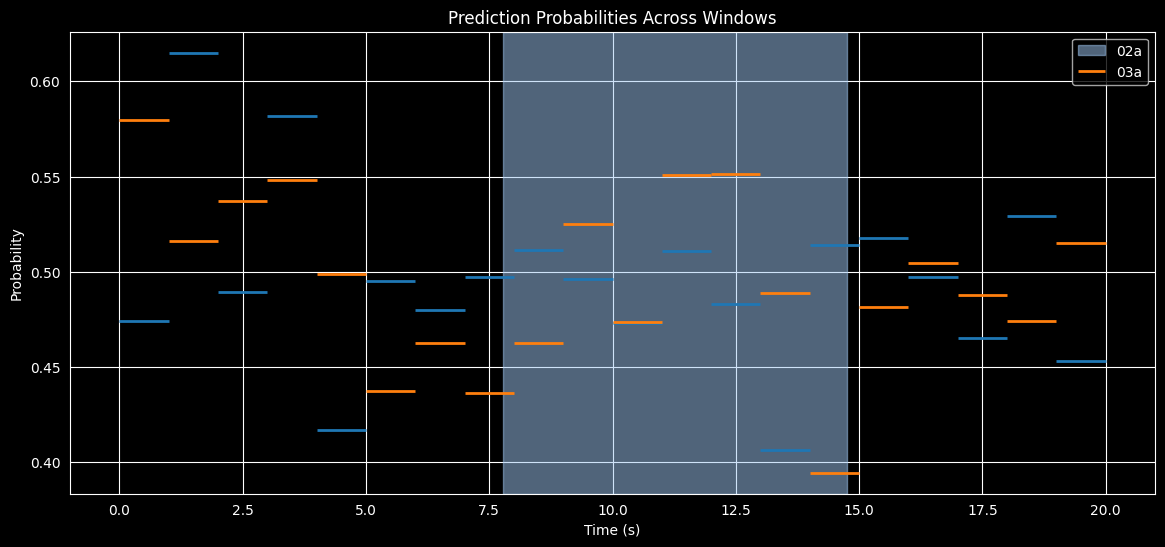

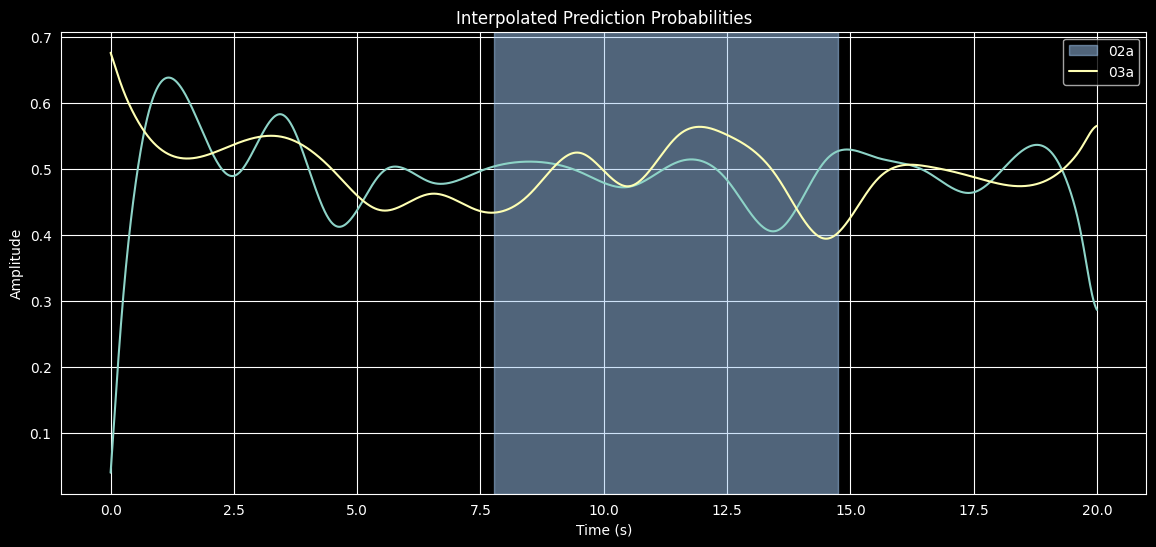

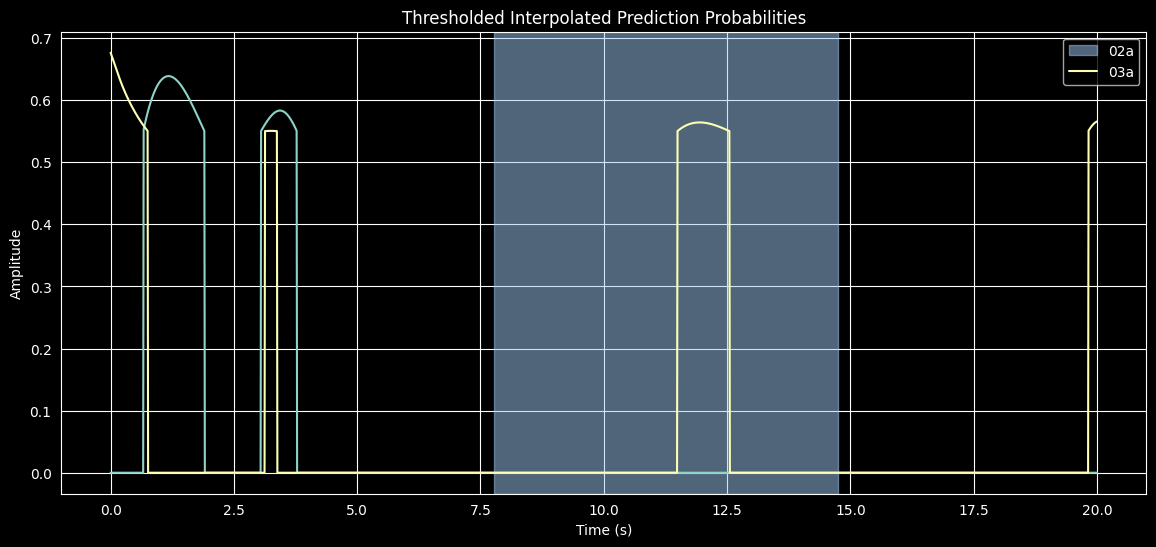

In [26]:
from caits.performance.evaluation import robustness_analysis

results = robustness_analysis(
    model = model,
    input_data = transormed_instance,
    class_names = CLASS_NAMES,
    sr = SAMPLE_RATE,
    ws = WS_SECONDS,
    overlap_percentage = OVERLAP_PERCENTAGE,
    ground_truths = ground_truths,
    cutoff = 2,
    repeats = 50,
    metrics = "all",
    interp_choice=2,
    prob_th = 0.55,
    dur_th = .1,
    iou_th = 0.7,
)

In [27]:
results["Insertions"], results["deletions"], results["substitutions"], results["corrects"]

(5, 1, 0, 0)

In [28]:
results["DR"], results["ERER"], results["Reliability"]

(0.0, 6.0, 0.0)

### Pipeline construcioni

In [29]:
SAMPLE_RATE * WS_SECONDS

100.0

In [30]:
from caits.filtering import filter_median_gen
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from caits.transformers import SklearnWrapper, ColumnTransformer, FeatureExtractorSignal, FunctionTransformer
from caits.transformers import SlidingWindow

slidingWindow = SlidingWindow(window_size=int(SAMPLE_RATE * WS_SECONDS), overlap=int(OVERLAP_PERCENTAGE * SAMPLE_RATE * WS_SECONDS))

pipe_filter = Pipeline(
    [   
        ("median", FunctionTransformer(filter_median_gen, window_size=10)),
        ("butterworth", FunctionTransformer(filter_butterworth, fs=10, filter_type='highpass', cutoff_freq=2))
    ]
)

pipe_scaler = SklearnWrapper(
    sklearn_transformers=[
        ("scaler", StandardScaler, {}),
    ],
    to_X=True,
    to_y=False
)

mag_tr = FeatureExtractorSignal(
    [
        {
            "func": magnitude_signal,
        }
    ]
)

column_tr1 = ColumnTransformer(
    [
        (
            "filter_acc_x_gyr_x",
            pipe_filter,
            {
                "X": (["acc_x_axis_g", "gyr_x_axis_deg/s"], None)
            }
        ),
        (
            "filter_acc_y_gyr_y",
            pipe_filter,
            {
                "X": (["acc_y_axis_g", "gyr_y_axis_deg/s"], None)
            }
        )
    ],
)

column_tr2 = ColumnTransformer(
    [
        (
            "scale_acc_x_acc_y_acc_z",
            pipe_scaler,
            {
                "X": (["acc_x_axis_g", "acc_y_axis_g", "acc_z_axis_g"], ["new_acc_x", "new_acc_y", "new_acc_z"])
            }
        )
    ],
)

column_tr3 = ColumnTransformer(
    [
        (
            "mag_calc_1",
            mag_tr,
            {
                "X": (["acc_x_axis_g", "acc_y_axis_g", "acc_z_axis_g"], ["mag_acc"])
            }
        ),
        (
            "mag_calc_2",
            mag_tr,
            {
                "X": (["gyr_x_axis_deg/s", "gyr_y_axis_deg/s", "gyr_z_axis_deg/s"], ["mag_gyr"])
            }
        ),
        (
            "mag_calc_3",
            mag_tr,
            {
                "X": (["new_acc_x", "new_acc_y", "new_acc_z"], ["new_mag_gyr"])
            }
        )
    ],
)

final_pipe = Pipeline(
    [
        ("sw", slidingWindow),
        ("filter", column_tr1),
        ("scale", column_tr2),
        ("mag", column_tr3),
    ]
)
final_pipe

Pipeline(steps=[('sw', SlidingWindow(overlap=0, window_size=100)),
                ('filter',
                 ColumnTransformer(transformations=[('filter_acc_x_gyr_x',
                                                     Pipeline(steps=[('median',
                                                                      FunctionTransformer(func=<function filter_median_gen at 0x7f5c99c9ed40>,
                                                                                          window_size=10)),
                                                                     ('butterworth',
                                                                      FunctionTransformer(cutoff_freq=2,
                                                                                          filter_type='highpass',
                                                                                          fs=10,
                                                                                          func=<function filter_butterwo...
                                                     FeatureExtractorSignal(feature_extractors=[{'func': <function magnitude_signal at 0x7f5c99d5dc60>}]),
                                                     {'X': (['gyr_x_axis_deg/s',
                                                             'gyr_y_axis_deg/s',
                                                             'gyr_z_axis_deg/s'],
                                                            ['mag_gyr'])}),
                                                    ('mag_calc_3',
                                                     FeatureExtractorSignal(feature_extractors=[{'func': <function magnitude_signal at 0x7f5c99d5dc60>}]),
                                                     {'X': (['new_acc_x',
                                                             'new_acc_y',
                                                             'new_acc_z'],
                                                            ['new_mag_gyr'])})]))])

In [31]:
transformed_pilot_data = final_pipe.fit_transform(datasetListObj)
transformed_pilot_data

DatasetList object with 65 instances

In [32]:
for i in range(5):
    dataset_instance = datasetListObj[i]
    print(dataset_instance.X, dataset_instance.y)
    break

[      acc_x_axis_g  acc_y_axis_g  acc_z_axis_g  gyr_x_axis_deg/s  gyr_y_axis_deg/s  gyr_z_axis_deg/s  
   0        -0.448        -0.876        -0.184            -0.061             0.732             0.244  
   1        -0.452        -0.875        -0.185            -0.244             0.732             0.244  
   2        -0.453        -0.873        -0.185            -0.244             0.793             0.061  
   3        -0.455        -0.872        -0.186            -0.183             0.549            -0.122  
   4        -0.457        -0.871        -0.188            -0.366             0.427            -0.183  
 ...           ...           ...           ...               ...               ...               ...  
1995        -0.423        -0.889        -0.184            -1.403            -0.366             -0.61  
1996        -0.423        -0.891        -0.191            -1.403            -0.183            -0.732  
1997        -0.424        -0.891        -0.191            -1.342        

Evaluating instance: 02a_777_1475_02a_8_0_100_AccGyr_1_1_1_0_00_61964f51d11ec26c3bbde60c
[['02a']]
Predicted Events: [(0, 45, 0), (549, 567, 0), (726, 765, 0), (1841, 1923, 0), (0, 25, 1), (210, 303, 1), (1204, 1307, 1), (1753, 1848, 1)]
Ground truth Events: [(777, 1475, 0)]
Evaluating instance: 02a_524_946_02a_1_0_100_AccGyr_1_1_1_0_00_61683eb7ed1368992649f25f
[['02a']]
Predicted Events: [(1060, 1174, 0), (0, 76, 1), (328, 377, 1), (684, 774, 1)]
Ground truth Events: [(524, 946, 0)]
Evaluating instance: 03a_1753_2417_03a_3_0_100_AccGyr_1_1_1_0_00_61683eb7ed1368992649f257
[['03a']]
Predicted Events: [(0, 29, 0), (601, 636, 0), (923, 1066, 1), (1402, 1453, 1), (1973, 2000, 1)]
Ground truth Events: [(1753, 2417, 1)]


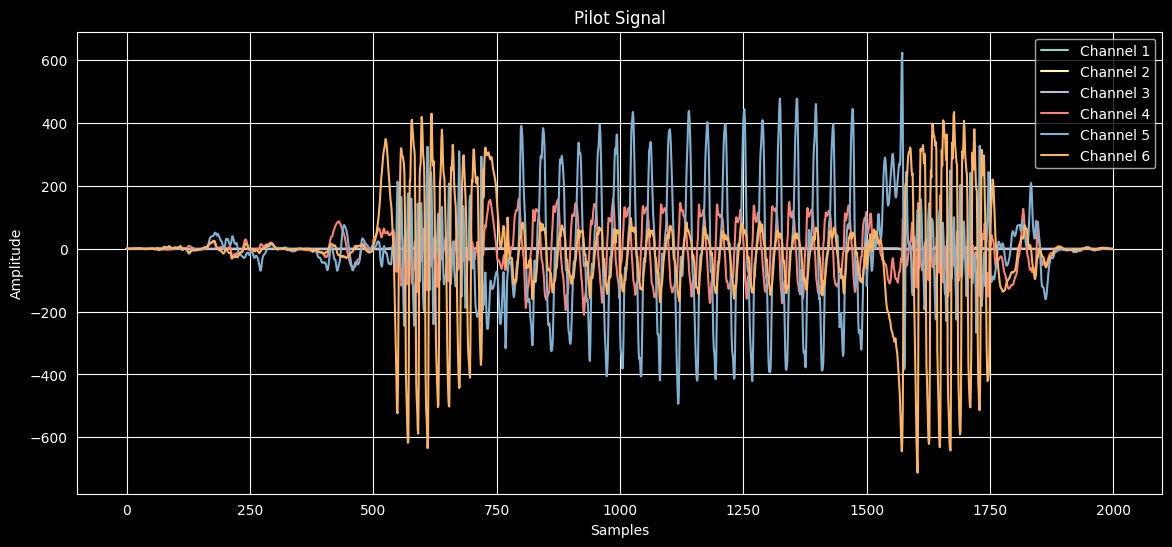

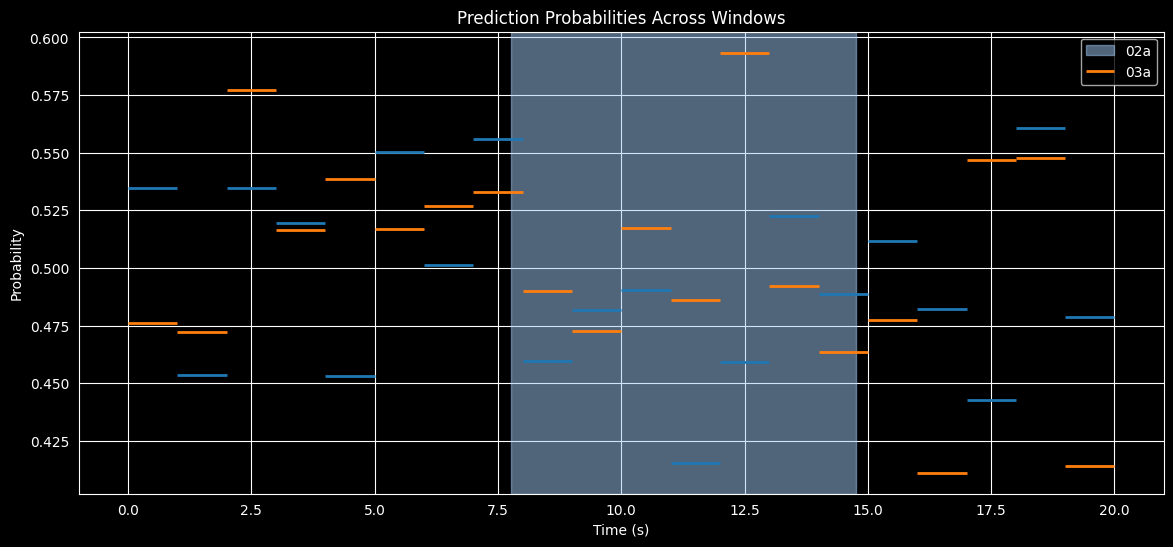

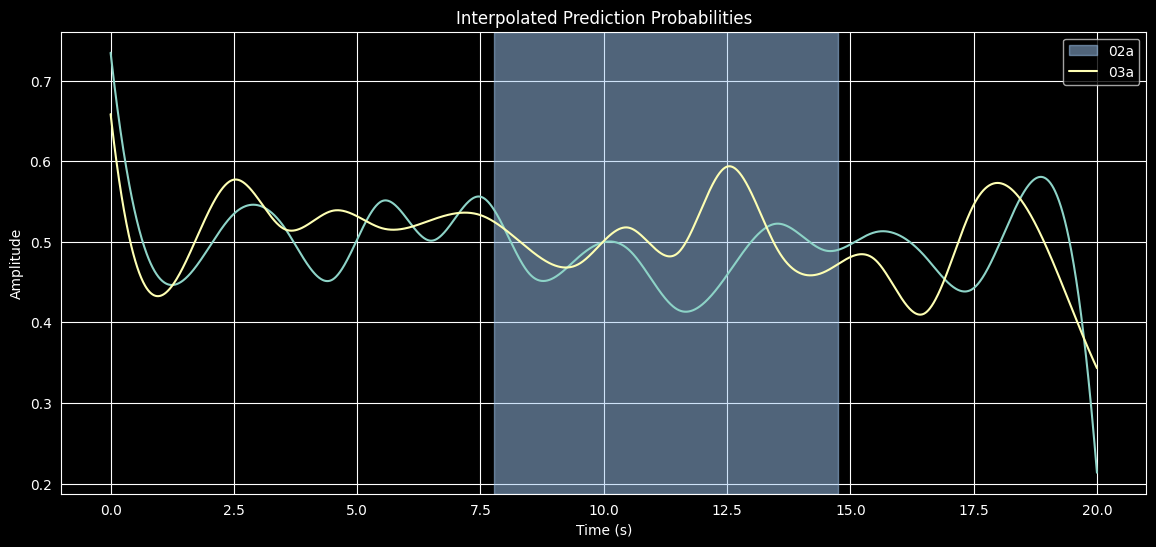

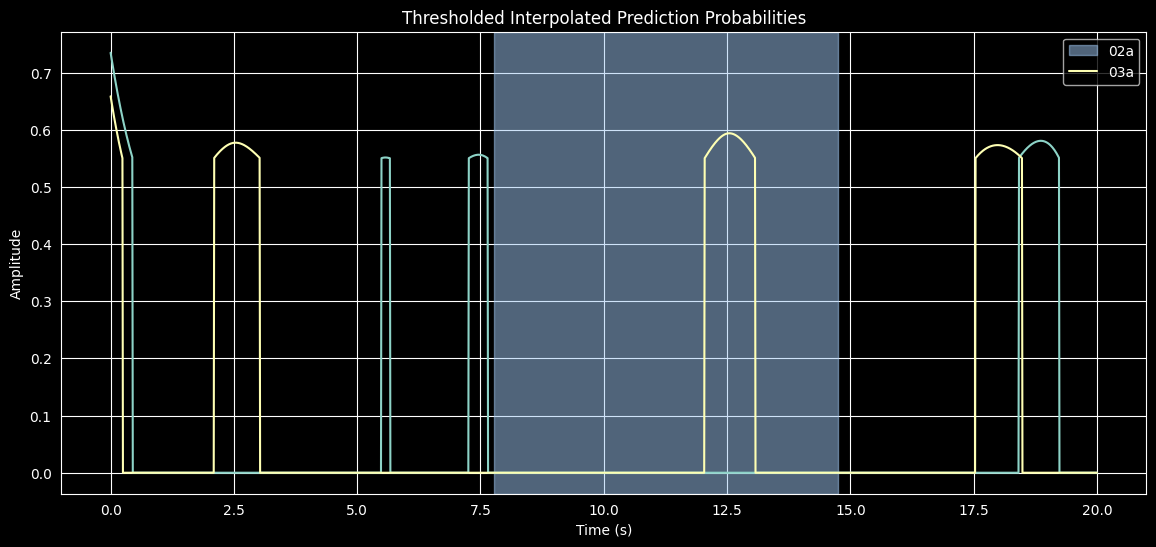

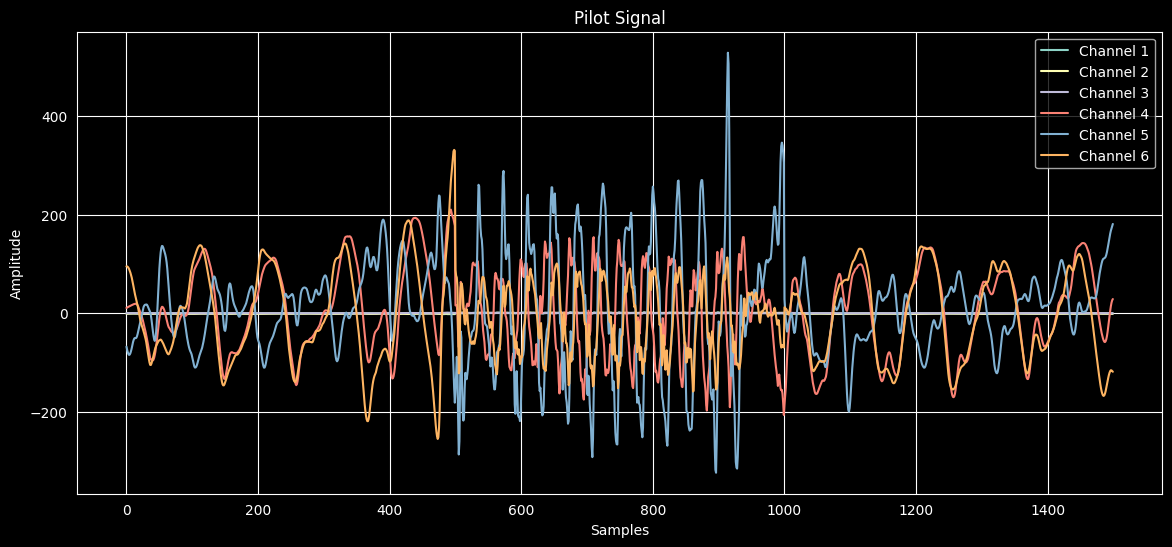

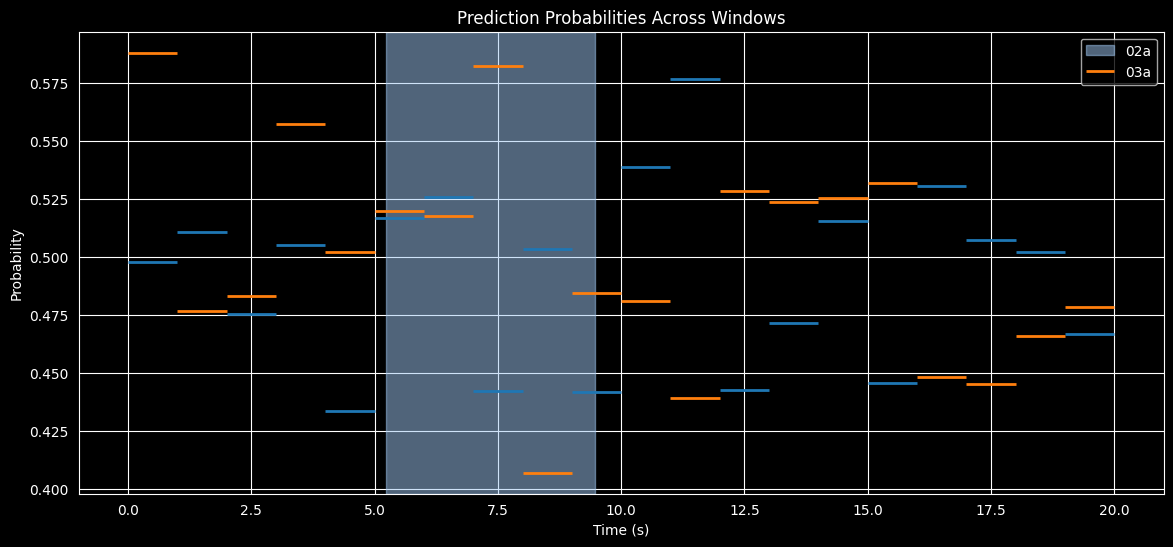

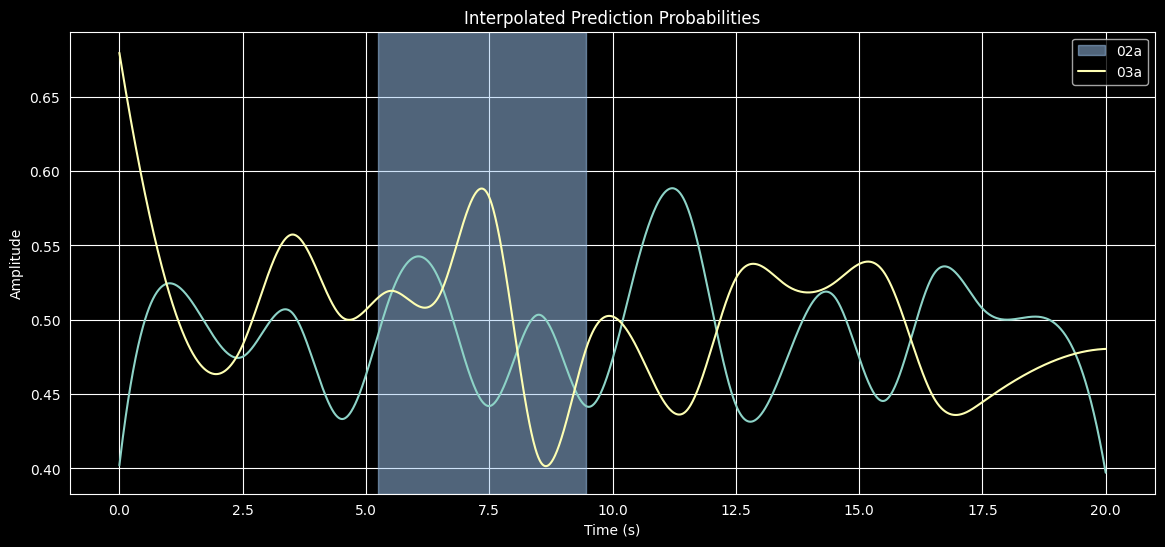

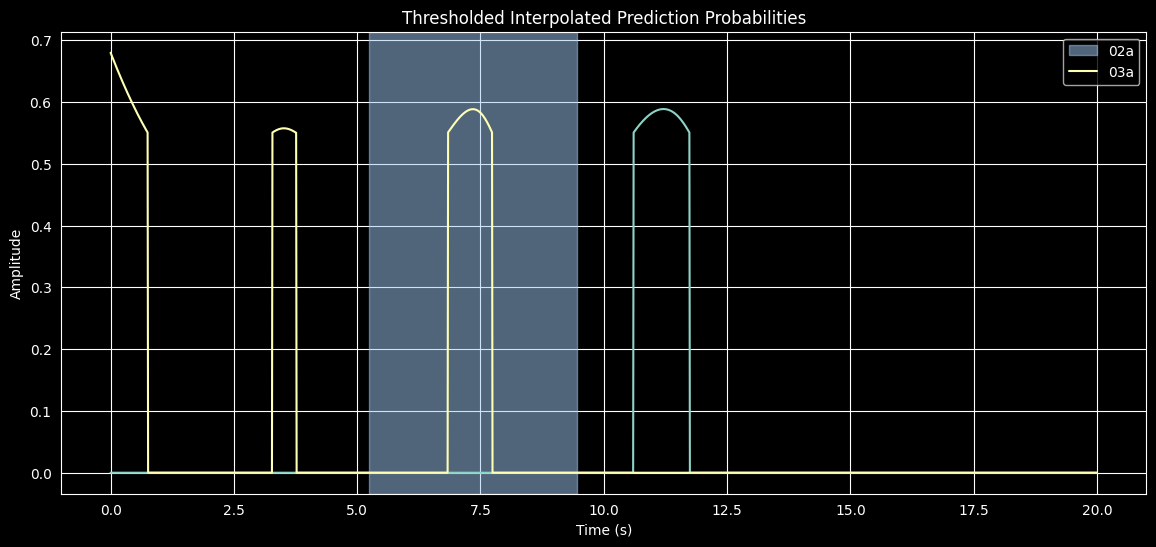

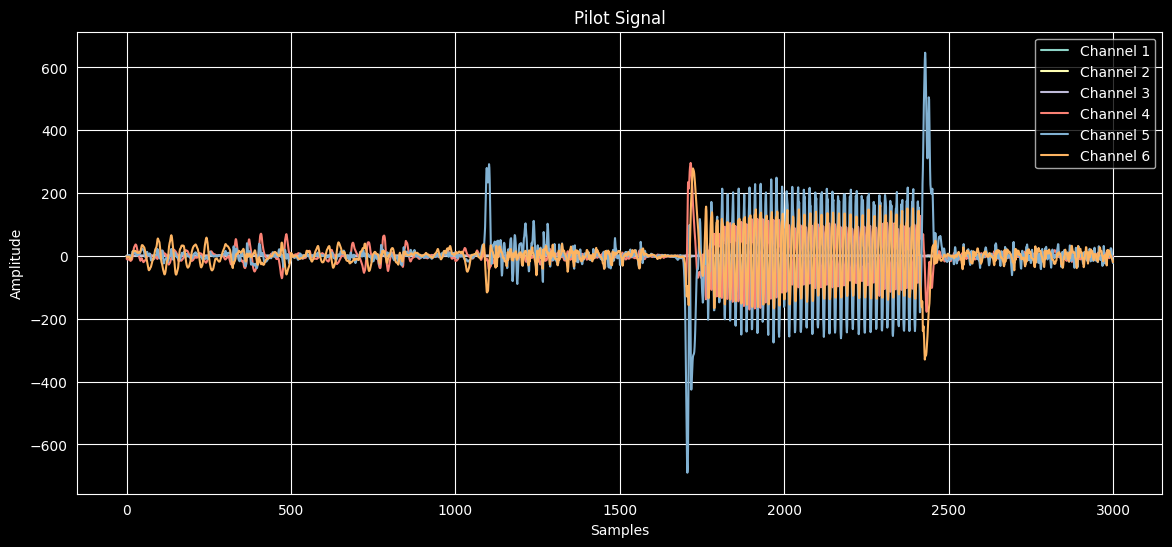

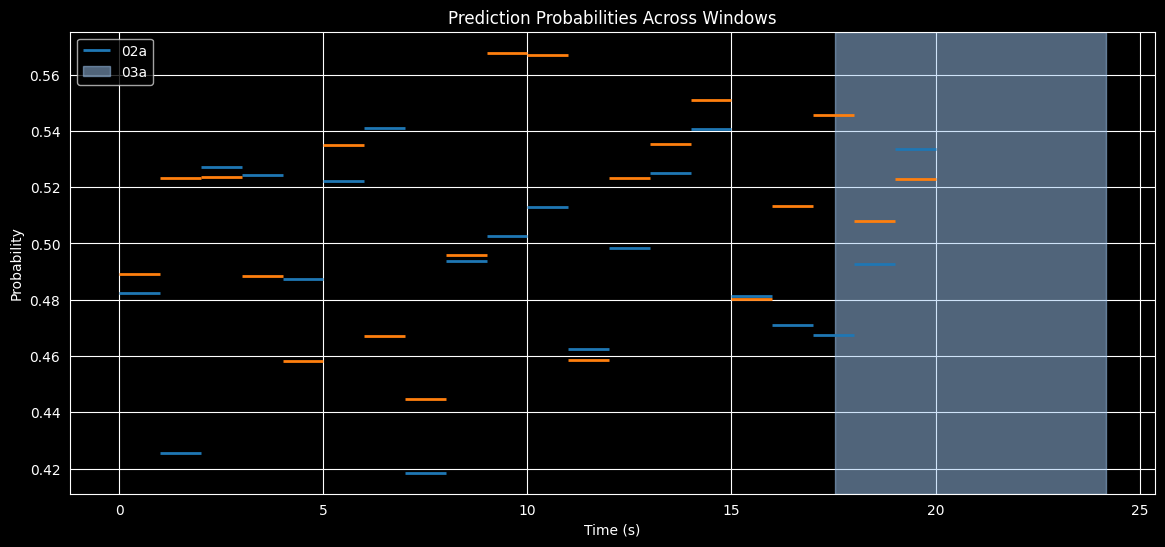

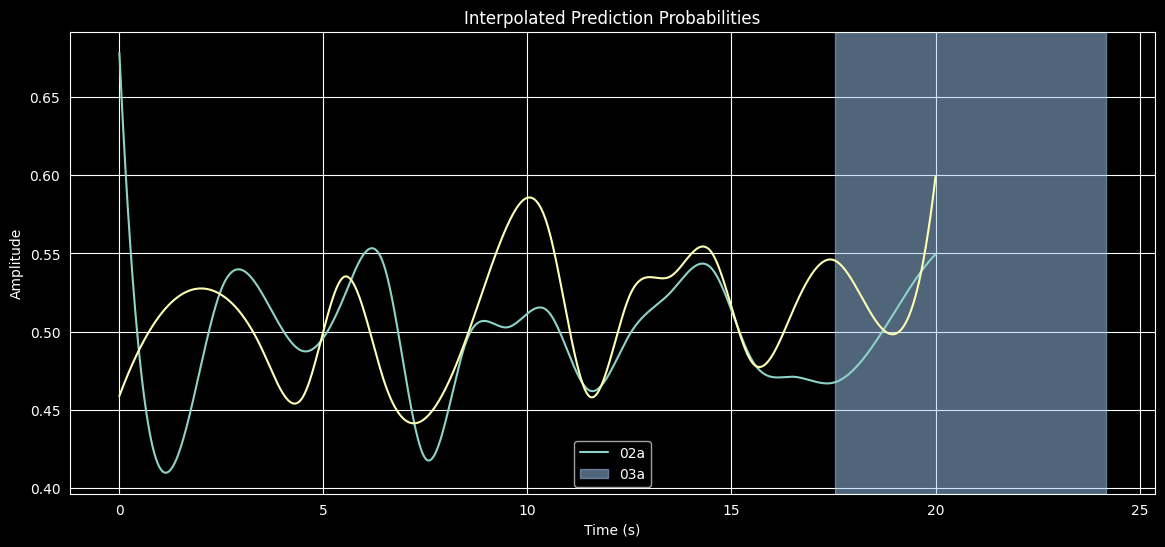

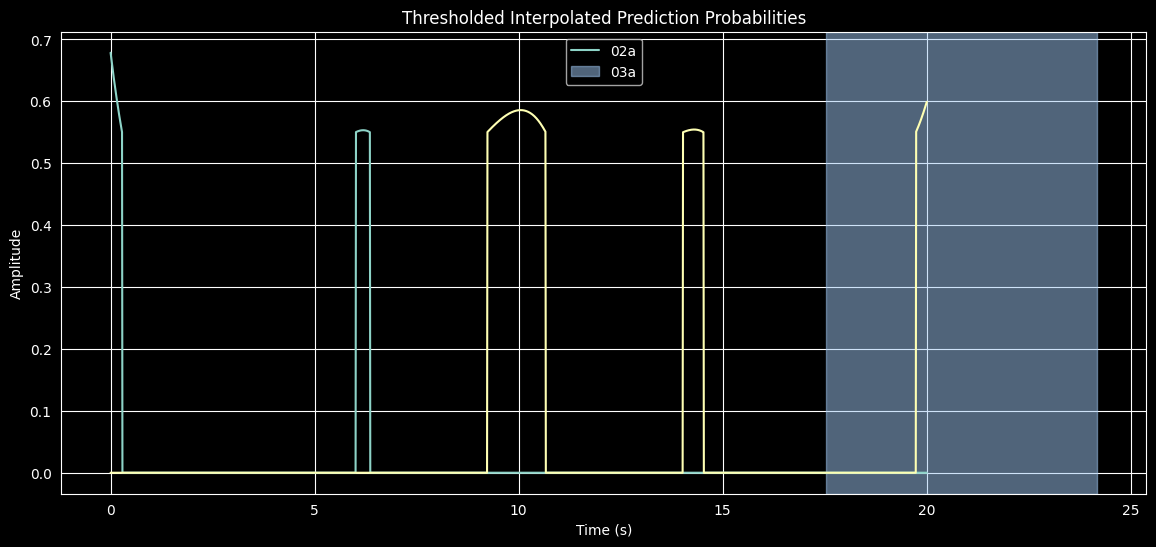

In [33]:
from caits.performance.evaluation import robustness_analysis_batch

total_results = robustness_analysis_batch(
    pipeline=final_pipe,
    model=model,
    dataset=datasetListObj,
    class_names=CLASS_NAMES,
    events=events_dict,
    sample_rate=SAMPLE_RATE,
    ws=WS_SECONDS,
    perc_overlap=OVERLAP_PERCENTAGE,
    cutoff=10,
    repeats=50,
    metrics="all",
    prob_th=0.55,
    duration_th=0.1,
    iou_th=0.3,
    options_to_include=[]
)